Цель работы: изучение алгоритмов и методов классификации на практике.

Вариант: 2.

Задание:
- Загрузить набор данных.
- Провести предварительную обработку данных.
- Выделить целевую переменную, которую необходимо предсказать. Не включать эту целевую переменную в модель. Построить матрицу диаграмм рассеяния, выделив значения целевой переменной разными цветами.
- Разбить набор данных на тренировочной и тестовый датасеты с помощью train_test_split и выполнить стандартизацию числовых данных.
- Разработать предсказательную модель качественного отклика методами классификации (для оценки 5 – kNN, дерево решений, логистическая регрессия, случайный лес).
- Оценить ошибку классификации для каждого метода. Подсчитать метрики: Accuracy, Precision, Recall, Balanced accuracy, F1 score.
- Построить матрицу неточностей с помощью confusion_matrix для каждого метода.
- Построить графики ROC-кривой для каждого метода на одном графике для сравнения.
- Сделать вывод о качестве построенного классификатора по подсчитанным выше метрикам.

Набор данных - employee_attrition.csv.

Описание набора данных employee_attrition.csv:
- age – возраст сотрудника (лет), числовой.
- gender – пол: M / F, категориальный.
- department – департамент: Sales / Engineering / HR / Finance / Support, категориальный.
- job_level – грейд должности (1–5), целочисленный.
- marital_status – семейное положение: Single / Married / Divorced, категориальный.
- monthly_income – месячный доход, USD/мес, числовой.
- years_at_company – годы в компании, целочисленный.
- overtime – переработки: Yes / No, категориальный.
- performance_rating – оценка эффективности (1–4), целочисленный порядковый.
- distance_from_home_km – расстояние от дома до офиса, км, числовой.
- training_hours_last_year – часы обучения за прошлый год, целочисленный.
- Attrition – целевой класс: 1 – уволился, 0 – остался.

# 1. Загрузка и предварительная обработка данных

На этом шаге загружается набор данных employee_attrition из папки datasets, выполняется первичный осмотр структуры датафрейма и базовая описательная статистика по числовым признакам.

Дополнительно выводятся несколько первых строк таблицы и распределения по ключевым категориальным столбцам. Это позволяет оценить состав выборки и понять, какие признаки будут использоваться на следующих этапах предобработки и обучения моделей классификации.

In [19]:
import numpy as np
import pandas as pd

seed = 12122025

# загрузка датасета employee_attrition и первичный осмотр
emp_df = pd.read_csv("datasets/employee_attrition.csv")

print("размер датасета:", emp_df.shape)

print("первые строки датафрейма:")
display(emp_df.head())

print("информация о столбцах:")
display(emp_df.info())

print("описательная статистика по числовым признакам:")
display(emp_df.describe())

print("распределение по департаментам:")
display(emp_df["department"].value_counts())

print("распределение по целевой переменной Attrition:")
display(emp_df["Attrition"].value_counts())


размер датасета: (3048, 12)
первые строки датафрейма:


,age,gender,department,job_level,marital_status,monthly_income,years_at_company,overtime,performance_rating,distance_from_home_km,training_hours_last_year,Attrition
0,31,F,Engineering,1,Single,5163.0,14,No,3,24.1,141.0,0
1,29,M,Sales,2,Divorced,13878.0,1,No,3,4.6,141.0,0
2,26,F,Support,1,Married,4712.0,6,No,3,8.4,148.0,0
3,61,F,Engineering,2,Single,12196.0,12,Yes,4,2.2,98.0,0
4,59,F,Sales,5,Single,15823.0,18,No,4,7.2,10.0,0


информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3048 entries, 0 to 3047
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3048 non-null   int64  
 1   gender                    3048 non-null   object 
 2   department                3048 non-null   object 
 3   job_level                 3048 non-null   int64  
 4   marital_status            3048 non-null   object 
 5   monthly_income            3048 non-null   float64
 6   years_at_company          3048 non-null   int64  
 7   overtime                  3048 non-null   object 
 8   performance_rating        3048 non-null   int64  
 9   distance_from_home_km     3048 non-null   float64
 10  training_hours_last_year  3048 non-null   float64
 11  Attrition                 3048 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 285.9+ KB


None

описательная статистика по числовым признакам:


,age,job_level,monthly_income,years_at_company,performance_rating,distance_from_home_km,training_hours_last_year,Attrition
count,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000
mean,41.308071,2.188976,7727.857283,20.102362,2.838583,10.236490,104.930118,0.091207
std,13.431709,1.165800,4058.833918,11.826501,0.733775,9.208483,76.474385,0.287951
min,18.000000,1.000000,1488.000000,0.000000,1.000000,-1.900000,0.000000,0.000000
25%,30.000000,1.000000,4901.750000,10.000000,2.000000,4.100000,50.000000,0.000000
50%,42.000000,2.000000,6733.000000,20.000000,3.000000,8.200000,102.000000,0.000000
75%,53.000000,3.000000,9529.500000,30.000000,3.000000,14.100000,151.000000,0.000000
max,64.000000,5.000000,35395.000000,40.000000,4.000000,99.840000,735.000000,1.000000


распределение по департаментам:


department
Engineering    1051
Sales           788
Support         526
Finance         443
HR              240
Name: count, dtype: int64

распределение по целевой переменной Attrition:


Attrition
0    2770
1     278
Name: count, dtype: int64

## 1.1 Проверка текстовых признаков

Перед дальнейшей обработкой целесообразно проверить текстовые признаки на наличие неявных дубликатов.

К неявным дубликатам относятся значения, которые визуально выглядят одинаково, но отличаются парой символов. Поэтому на данном шаге выводятся уникальные значения (в виде частот) по каждому текстовому признаку.


In [20]:
# проверка текстовых признаков на неявные дубликаты
obj_cols = emp_df.select_dtypes(include="object").columns.tolist()

print("текстовые признаки:")
display(pd.DataFrame({"obj_cols": obj_cols}))

for col in obj_cols:
    display(emp_df[col].value_counts())


текстовые признаки:


,obj_cols
0,gender
1,department
2,marital_status
3,overtime


gender
M    1539
F    1509
Name: count, dtype: int64

department
Engineering    1051
Sales           788
Support         526
Finance         443
HR              240
Name: count, dtype: int64

marital_status
Married     1470
Single      1220
Divorced     358
Name: count, dtype: int64

overtime
No     2201
Yes     847
Name: count, dtype: int64

## 1.2 Удаление явных дубликатов и анализ нетипичных значений

На этапе предварительной обработки проверяются и удаляются явные дубликаты строк.

Далее выполняется поиск значений, которые не соответствуют смыслу признаков. Для признака distance_from_home_km отрицательные значения являются некорректными.

На данном шаге выводится количество таких значений и описательная статистика только по отрицательной части выборки. На основании этих результатов в следующем шаге принимается решение о способе обработки обнаруженных значений.


In [21]:
# удаление явных дубликатов и анализ нетипичных значений

# удаление полных дубликатов строк
duplicate_count = int(emp_df.duplicated().sum())
print("число полных дубликатов:", duplicate_count)

emp_df = emp_df.drop_duplicates().reset_index(drop=True)
print("размер датасета после удаления дубликатов:", emp_df.shape)

# анализ отрицательных значений расстояния до офиса
distance_col = "distance_from_home_km"
negative_mask = emp_df[distance_col] < 0
negative_count = int(negative_mask.sum())

print("число отрицательных значений distance_from_home_km:", negative_count)
print("описательная статистика по отрицательным значениям distance_from_home_km:")
display(emp_df.loc[negative_mask, [distance_col]].describe())

число полных дубликатов: 0
размер датасета после удаления дубликатов: (3048, 12)
число отрицательных значений distance_from_home_km: 113
описательная статистика по отрицательным значениям distance_from_home_km:


,distance_from_home_km
count,113.000000
mean,-0.714159
std,0.458037
min,-1.900000
25%,-1.000000
50%,-0.600000
75%,-0.400000
max,-0.100000


По результатам анализа отрицательные значения distance_from_home_km встречаются в 113 наблюдениях и находятся в диапазоне от –1.9 до –0.1.

Так как отрицательное расстояние не имеет физического смысла, а величина отклонения небольшая, отрицательные значения заменяются на 0.

In [22]:
# замена отрицательных значений distance_from_home_km на 0

distance_col = "distance_from_home_km"
negative_mask = emp_df[distance_col] < 0
negative_count = int(negative_mask.sum())

print("число отрицательных значений distance_from_home_km до исправления:", negative_count)

emp_df.loc[negative_mask, distance_col] = 0

print("минимальное значение distance_from_home_km после исправления:", emp_df[distance_col].min())
print("число отрицательных значений distance_from_home_km после исправления:", (emp_df[distance_col] < 0).sum())


число отрицательных значений distance_from_home_km до исправления: 113
минимальное значение distance_from_home_km после исправления: 0.0
число отрицательных значений distance_from_home_km после исправления: 0


По результатам первичного анализа датасет employee_attrition содержит 3048 записей и 12 столбцов, среди которых 8 числовых признаков и 4 категориальных. Пропусков в данных не обнаружено.

В качестве целевой переменной для анализа выбирается столбец Attrition, который отражает факт увольнения сотрудника (1 – сотрудник уволился, 0 – остался).

Распределение по департаментам неоднородно: наибольшее число сотрудников работает в Engineering и Sales, тогда как HR и Finance представлены меньшими группами. Целевая переменная Attrition несбалансирована (2770 наблюдений класса 0 и 278 наблюдений класса 1), поэтому при оценке качества моделей необходимо учитывать не только долю верных ответов, но и метрики, чувствительные к дисбалансу классов.

По описательной статистике обнаружены нетипичные значения, не соответствующие смыслу признаков (отрицательные значения distance_from_home_km). Всего выявлено 113 таких значений в диапазоне от –1.9 до –0.1, после чего они заменены на 0.

# 2. Матрица диаграмм рассеяния

На данном шаге для числовых признаков строится матрица диаграмм рассеяния, а объекты раскрашиваются по значению Attrition. Это позволяет визуально оценить различия между классами и возможные зависимости между признаками.


числовые признаки для построения матрицы диаграмм рассеяния:


,num_cols
0,age
1,job_level
2,monthly_income
3,years_at_company
4,performance_rating
5,distance_from_home_km
6,training_hours_last_year


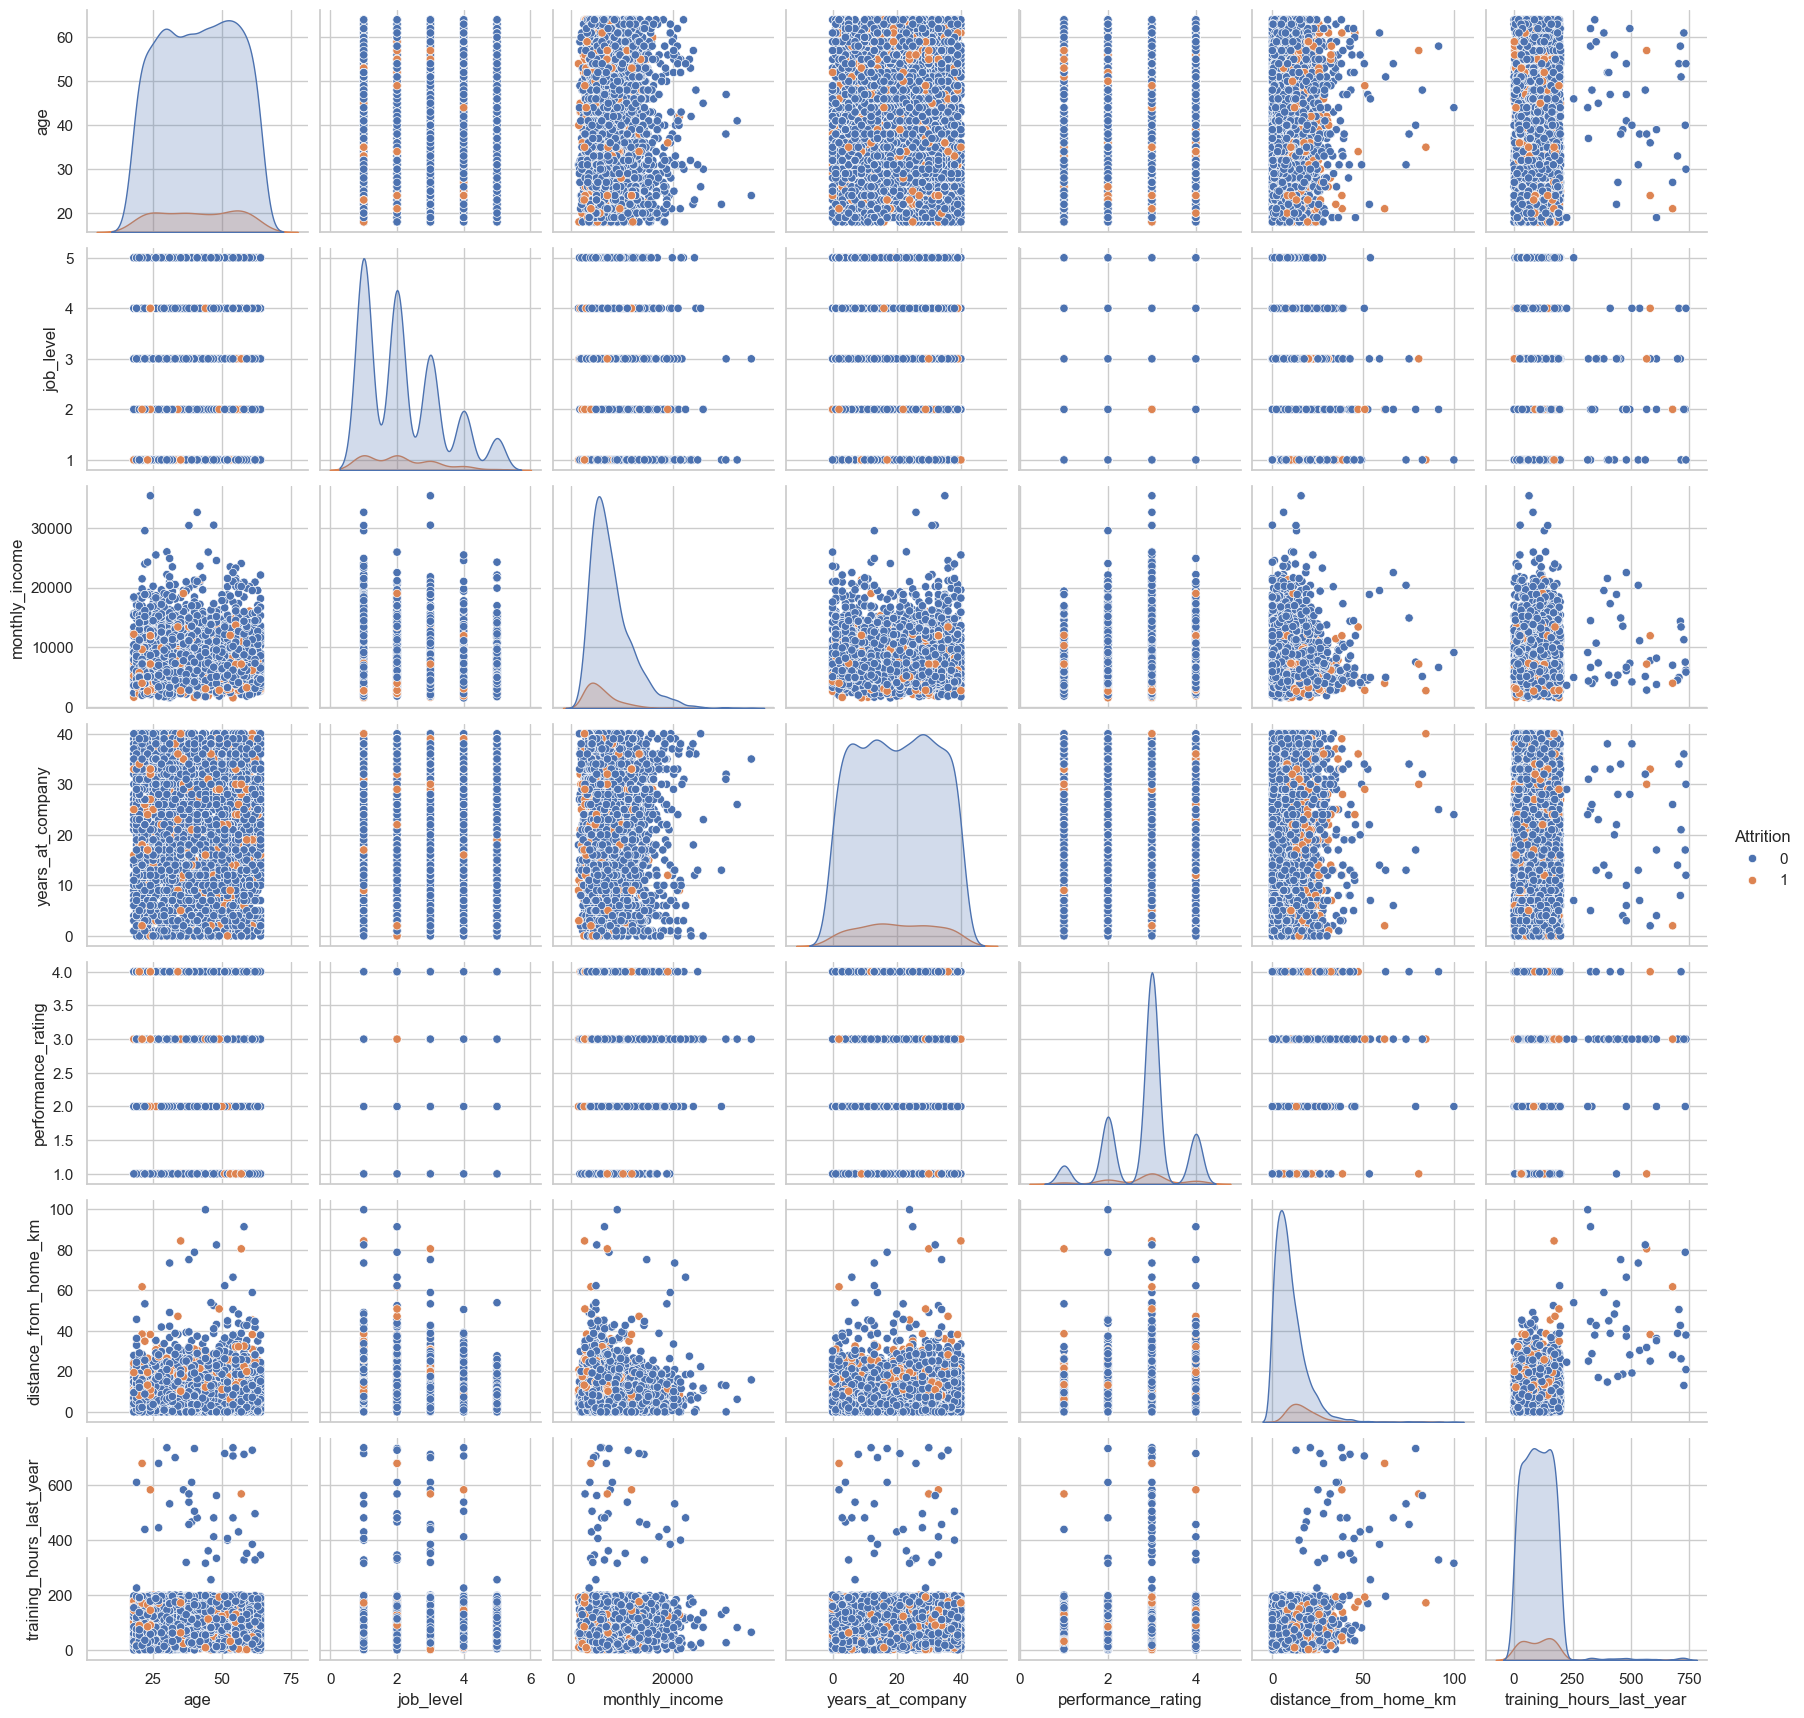

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

target_col = "Attrition"

y = emp_df[target_col].copy()
X = emp_df.drop(columns=[target_col]).copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("числовые признаки для построения матрицы диаграмм рассеяния:")
display(pd.DataFrame({"num_cols": num_cols}))

sns.pairplot(emp_df, vars=num_cols, hue=target_col)
plt.show()


По матрице диаграмм рассеяния видно, что классы Attrition сильно перекрываются по большинству числовых признаков. Это означает, что одних только парных зависимостей недостаточно для чёткого разделения классов и далее требуется обучение моделей, которые учитывают комбинации признаков.

Также на графиках заметен дисбаланс классов: наблюдений Attrition = 1 существенно меньше, чем Attrition = 0. В таких условиях визуальная оценка различий осложняется, а при построении моделей важно ориентироваться не только на общую долю верных ответов.

По распределениям и диаграммам рассеяния можно отметить, что точки Attrition = 1 встречаются по всему диапазону значений признаков. При этом выраженных границ, по которым можно однозначно отделить уволившихся сотрудников от оставшихся, не наблюдается.

Таким образом, матрица диаграмм рассеяния используется как предварительный визуальный этап. Основные выводы о значимости признаков и качестве разделения классов будут сделаны после обучения классификаторов и расчёта метрик качества.

# 3. Разбиение данных и стандартизация

На данном шаге набор данных разбивается на обучающую и тестовую выборки. Обучающая выборка используется для обучения моделей и всех преобразований признаков, тестовая – только для проверки качества уже обученной модели.

Далее выполняется масштабирование числовых признаков. Масштабирование нужно, потому что многие алгоритмы используют расстояния между объектами или чувствительны к масштабу признаков. Если один признак измеряется в больших числах, а другой в маленьких, то без масштабирования вклад признаков в работу модели будет несопоставимым.

В рамках работы рассматриваются три способа масштабирования: StandardScaler, MinMaxScaler и MaxAbsScaler.

StandardScaler выполняет стандартизацию: каждое значение признака преобразуется так, чтобы среднее значение признака стало равно 0, а стандартное отклонение стало равно 1. Для каждого числового признака x рассчитываются среднее u и стандартное отклонение s по обучающей выборке, после чего применяется формула:
z = (x - u) / s.
В результате признаки приводятся к единому масштабу относительно своего разброса. Такой подход удобен, когда важно сравнивать значения признаков по отклонению от среднего и когда признаки изначально имеют разные диапазоны.

MinMaxScaler выполняет нормализацию: каждое значение признака переводится в заданный диапазон, обычно от 0 до 1. Для каждого признака по обучающей выборке находятся минимум xmin и максимум xmax, после чего применяется формула:
z = (x - xmin) / (xmax - xmin).
В результате минимальное значение признака становится 0, максимальное 1, а остальные значения распределяются между ними. Этот способ удобно использовать, когда требуется сжать признаки в одинаковый диапазон и сохранить относительный порядок значений.

MaxAbsScaler масштабирует признак делением на максимальное по модулю значение. Для каждого признака по обучающей выборке находится xmaxabs = max(|x|), после чего применяется формула z = x/xmaxabs
В результате значения оказываются в диапазоне [-1, 1] (если есть отрицательные значения) или [0, 1] (если все значения неотрицательны). В отличие от StandardScaler, этот способ не вычитает среднее, то есть не центрирует данные вокруг нуля, а только приводит масштаб к сопоставимому. Такой подход удобен, когда важно сохранить нулевые значения и структуру разреженных данных.

Основные различия методов:

StandardScaler приводит признаки к нулевому среднему и единичному стандартному отклонению, то есть учитывает разброс данных и центрирует распределение.

MinMaxScaler приводит признаки к фиксированному диапазону, обычно [0, 1], то есть масштаб зависит только от минимума и максимума в обучающей выборке.

MaxAbsScaler приводит признаки к диапазону по максимальному модулю, не меняя центр распределения и сохраняя нули.

Полученные варианты признаков будут использоваться далее при обучении моделей. Для каждого варианта будут рассчитаны метрики качества, что позволит сравнить влияние выбранного способа масштабирования на результат классификации.


In [24]:
from sklearn.model_selection import train_test_split

target_col = "Attrition"

y = emp_df[target_col].copy()
X = emp_df.drop(columns=[target_col]).copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# one-hot кодирование категориальных признаков
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y,
)

print("размеры выборок:")
display(
    pd.DataFrame(
        {
            "part": ["train", "test"],
            "X_shape": [X_train.shape, X_test.shape],
            "y_shape": [y_train.shape, y_test.shape],
        }
    )
)

print("распределение классов Attrition в train:")
display(y_train.value_counts())

print("распределение классов Attrition в test:")
display(y_test.value_counts())


размеры выборок:


,part,X_shape,y_shape
0,train,"(2133, 15)","(2133,)"
1,test,"(915, 15)","(915,)"


распределение классов Attrition в train:


Attrition
0    1938
1     195
Name: count, dtype: int64

распределение классов Attrition в test:


Attrition
0    832
1     83
Name: count, dtype: int64

In [25]:
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler, StandardScaler

# подготовка трёх вариантов масштабирования для числовых признаков
scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "maxabs": MaxAbsScaler(),
}

scaled_data = {}

for scaler_name in scalers:
    scaler = scalers[scaler_name]

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    scaled_data[scaler_name] = {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
    }


# 4. Разработка моделей классификации

На данном шаге разрабатываются предсказательные модели качественного отклика четырьмя методами:
- метод k-ближайших соседей
- дерево решений
- логистическая регрессия
- случайный лес

Каждая модель обучается на трёх вариантах масштабирования признаков: StandardScaler, MinMaxScaler и MaxAbsScaler. Предсказания и вероятности сохраняются для последующего расчёта метрик качества, построения матриц неточностей и ROC-кривых.

Далее приведено описание принципа работы каждого метода и указаны гиперпараметры, которые используются в библиотеке sklearn.

Метод k-ближайших соседей (KNeighborsClassifier).

Метод k-ближайших соседей используется для классификации и основан на том, что новому наблюдению присваивается класс по результатам голосования его k ближайших соседей из обучающей выборки. Обычно выбирают нечётное значение k, чтобы избежать ситуации ничьей при голосовании. Количество соседей задаётся параметром n_neighbors. Для поиска ближайших соседей используется метрика расстояния, чаще всего применяется евклидово расстояние. Метод является простым и интерпретируемым, однако при увеличении объёма данных и числа признаков вычисление расстояний становится затратным, а также качество может снижаться при неравномерном представлении классов.

Дерево решений (DecisionTreeClassifier).

Дерево решений представляет собой структуру, где внутренние узлы соответствуют проверкам признаков, ветви отражают результаты этих проверок, а листовые узлы содержат итоговый класс. Построение начинается с корневого узла, содержащего всю обучающую выборку. На каждом шаге выбирается признак, который наилучшим образом разделяет данные на классы по выбранной метрике, например по индексу Джини или энтропии Шеннона. Разбиение выполняется рекурсивно до выполнения условий остановки, например ограничения глубины дерева или достаточного количества объектов в листьях. Для управления сложностью дерева и снижения риска переобучения используются гиперпараметры max_depth, criterion и min_samples_leaf.

Логистическая регрессия (LogisticRegression).

Логистическая регрессия предсказывает вероятность принадлежности объекта к классу с помощью логистической функции, которая также называется сигмоидной. В ходе обучения подбираются параметры модели, после чего для новых объектов рассчитываются вероятности отнесения к классу и формируются предсказания. В структуре LogisticRegression настраиваются параметры solver, который определяет алгоритм оптимизации, и max_iter, задающий максимальное число итераций оптимизационного алгоритма.

Случайный лес (RandomForestClassifier).

Случайный лес относится к ансамблевым методам и комбинирует прогнозы нескольких деревьев решений для получения более стабильного и точного результата. При обучении строится набор деревьев, а итоговое предсказание формируется по агрегированию их результатов. В качестве основных гиперпараметров указываются n_estimators – количество деревьев в ансамбле, а также параметры деревьев criterion и max_depth, которые ограничивают глубину каждого дерева.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


model_names = ["knn", "decision_tree", "logistic_regression", "random_forest"]

model_results = {}

for scaler_name in scaled_data:
    X_train_current = scaled_data[scaler_name]["X_train"]
    X_test_current = scaled_data[scaler_name]["X_test"]
    y_train_current = scaled_data[scaler_name]["y_train"]
    y_test_current = scaled_data[scaler_name]["y_test"]

    model_results[scaler_name] = {}

    for model_name in model_names:
        if model_name == "knn":
            # обучение методом k-ближайших соседей, k задаётся параметром n_neighbors
            model = KNeighborsClassifier(n_neighbors=5)

        if model_name == "decision_tree":
            # обучение дерева решений с фиксированным random_state
            model = DecisionTreeClassifier(random_state=seed)

        if model_name == "logistic_regression":
            # обучение логистической регрессии, max_iter увеличен для устойчивой сходимости
            model = LogisticRegression(max_iter=1000, random_state=seed)

        if model_name == "random_forest":
            # обучение случайного леса, число деревьев задаётся параметром n_estimators
            model = RandomForestClassifier(n_estimators=100, random_state=seed)

        model.fit(X_train_current, y_train_current)

        y_pred = model.predict(X_test_current)
        y_proba = model.predict_proba(X_test_current)[:, 1]

        model_results[scaler_name][model_name] = {
            "model": model,
            "y_test": y_test_current,
            "y_pred": y_pred,
            "y_proba": y_proba,
        }

print("обучение завершено")
display(pd.DataFrame({"scaler": list(model_results.keys())}))
display(pd.DataFrame({"model": model_names}))


обучение завершено


,scaler
0,standard
1,minmax
2,maxabs


,model
0,knn
1,decision_tree
2,logistic_regression
3,random_forest


# 5. Оценка качества классификации

На данном шаге оценивается качество построенных классификаторов по метрикам.

Для бинарной классификации (классы 0 и 1) для каждого объекта возможны четыре исхода:
- TP (true positive) – модель предсказала 1 и истинное значение равно 1
- TN (true negative) – модель предсказала 0 и истинное значение равно 0
- FP (false positive) – модель предсказала 1, но истинное значение равно 0
- FN (false negative) – модель предсказала 0, но истинное значение равно 1

Метрики качества.

Accuracy – доля правильных ответов. Показывает отношение числа верных прогнозов к общему числу прогнозов.

Формула:
Accuracy = (TP + TN) / (TP + TN + FP + FN)

Precision – точность. Показывает, какая доля объектов, предсказанных как класс 1, действительно относится к классу 1.

Формула:
Precision = TP / (TP + FP)

Recall – полнота. Показывает, какая доля объектов класса 1 была обнаружена моделью.

Формула:
Recall = TP / (TP + FN)

F1 score – гармоническое среднее между Precision и Recall. Используется для совместной оценки точности и полноты.

Формула:
F1 = 2 * Precision * Recall / (Precision + Recall)

Balanced accuracy – сбалансированная точность. Является средним значением точности по каждому классу и используется при несбалансированных выборках.

Формула:
Balanced accuracy = (TPR + TNR) / 2,
где TPR = TP / (TP + FN),
TNR = TN / (TN + FP)

Так как целевая переменная Attrition несбалансирована, метрика Accuracy может быть недостаточно информативной. В дальнейшем для сравнения моделей используются также Precision, Recall, F1 score и Balanced accuracy.


In [27]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


rows = []

for scaler_name in model_results:
    for model_name in model_results[scaler_name]:
        y_test_current = model_results[scaler_name][model_name]["y_test"]
        y_pred_current = model_results[scaler_name][model_name]["y_pred"]

        acc = accuracy_score(y_test_current, y_pred_current)
        prec = precision_score(y_test_current, y_pred_current, zero_division=0)
        rec = recall_score(y_test_current, y_pred_current, zero_division=0)
        f1 = f1_score(y_test_current, y_pred_current, zero_division=0)
        bal_acc = balanced_accuracy_score(y_test_current, y_pred_current)

        rows.append(
            {
                "scaler": scaler_name,
                "model": model_name,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1_score": f1,
                "balanced_accuracy": bal_acc,
            }
        )

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.sort_values(by=["scaler", "model"]).reset_index(drop=True)

display(metrics_df)


,scaler,model,accuracy,precision,recall,f1_score,balanced_accuracy
0,maxabs,decision_tree,0.855738,0.218391,0.228916,0.223529,0.573592
1,maxabs,knn,0.908197,0.400000,0.024096,0.045455,0.510245
2,maxabs,logistic_regression,0.910383,1.000000,0.012048,0.023810,0.506024
3,maxabs,random_forest,0.910383,0.666667,0.024096,0.046512,0.511447
4,minmax,decision_tree,0.856831,0.220930,0.228916,0.224852,0.574193
5,minmax,knn,0.906011,0.200000,0.012048,0.022727,0.503620
6,minmax,logistic_regression,0.910383,1.000000,0.012048,0.023810,0.506024
7,minmax,random_forest,0.910383,0.666667,0.024096,0.046512,0.511447
8,standard,decision_tree,0.856831,0.207317,0.204819,0.206061,0.563347
9,standard,knn,0.910383,0.555556,0.060241,0.108696,0.527717


По полученным метрикам видно, что Accuracy во всех вариантах находится на высоком уровне (около 0.85–0.91). Это связано с тем, что целевая переменная Attrition несбалансирована и большинство объектов относится к классу 0, поэтому высокая Accuracy не гарантирует качественное выявление класса 1.

С точки зрения выявления уволившихся сотрудников (класс 1) ключевой метрикой является Recall. Наибольшие значения Recall получены у дерева решений для всех трёх способов масштабирования (Recall = 0.228916). При этом F1 score также является наибольшим среди всех рассмотренных вариантов (около 0.223–0.225), а Balanced accuracy достигает максимума (около 0.574).

Метод k-ближайших соседей чувствителен к масштабированию. При StandardScaler значения Recall и F1 score выше, чем при MinMaxScaler и MaxAbsScaler (Recall = 0.060241, F1 score = 0.108696), однако по Balanced accuracy данный вариант уступает дереву решений.

Логистическая регрессия и случайный лес в текущих настройках демонстрируют очень низкий Recall (0.012048–0.024096). При этом у логистической регрессии Precision достигает 1.0, что соответствует ситуации, когда модель предсказывает класс 1 крайне редко и пропускает большую часть объектов класса 1.

Таким образом, по совокупности метрик, устойчивых к дисбалансу классов (Recall, F1 score и Balanced accuracy), на данном этапе наиболее результативным является дерево решений. Для метода k-ближайших соседей наиболее удачным способом масштабирования является StandardScaler, однако итоговое качество по Balanced accuracy и F1 score остаётся ниже, чем у дерева решений.

# 6. Матрица неточностей

Матрица неточностей показывает, как именно классификатор ошибается.

Строки соответствуют истинным значениям, столбцы – предсказанным.

На данном шаге матрица неточностей строится для каждого метода классификации. Дополнительно сравниваются результаты для разных способов масштабирования признаков.


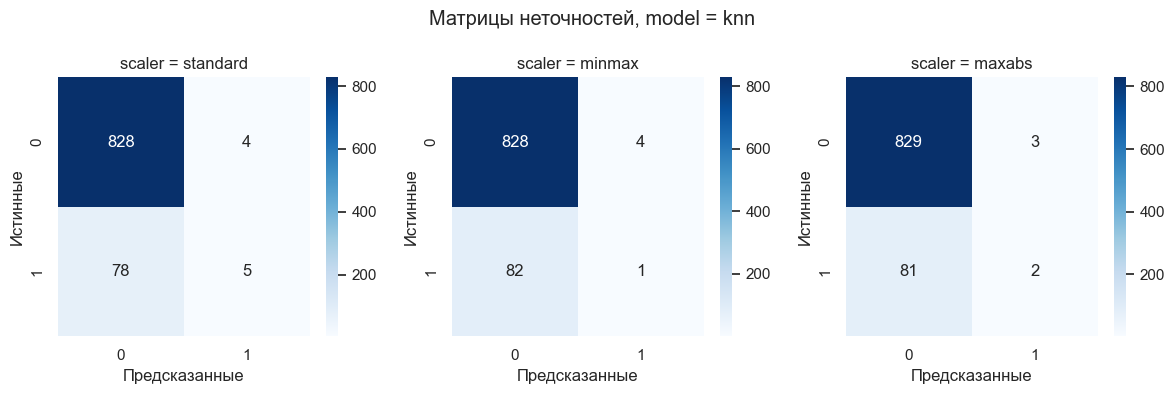

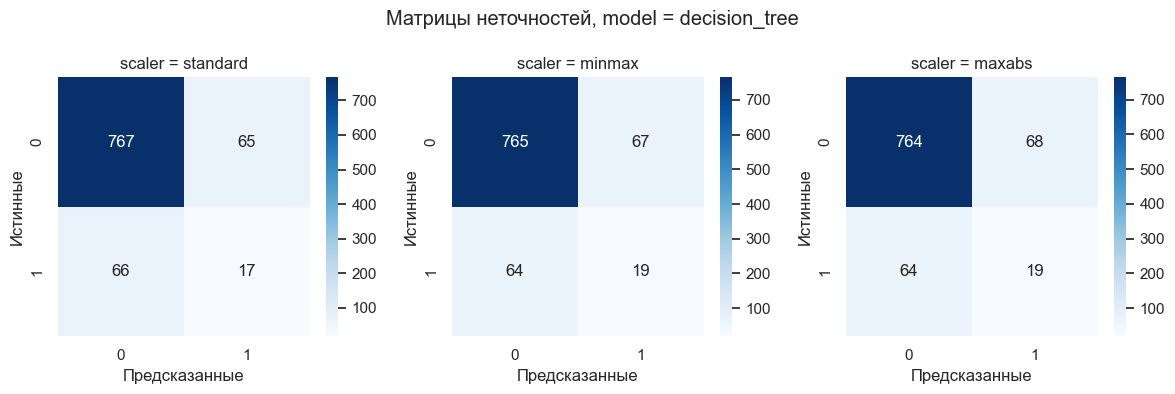

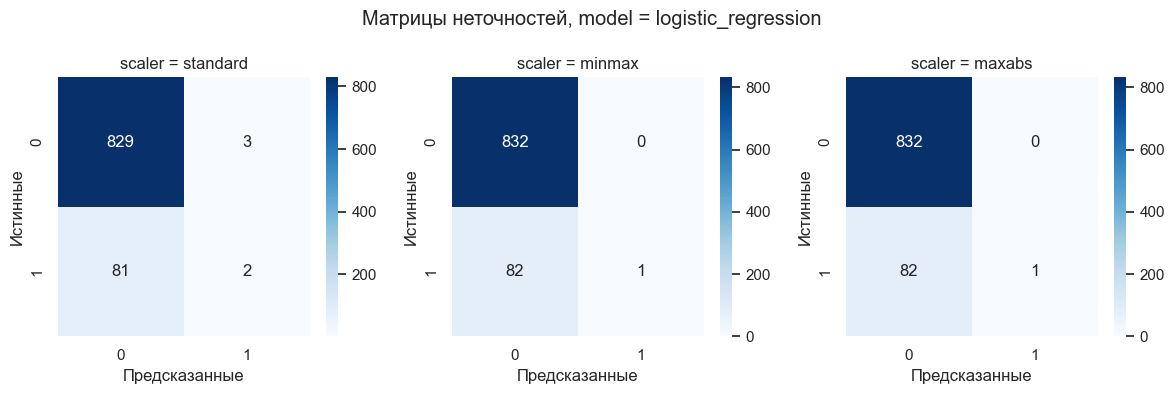

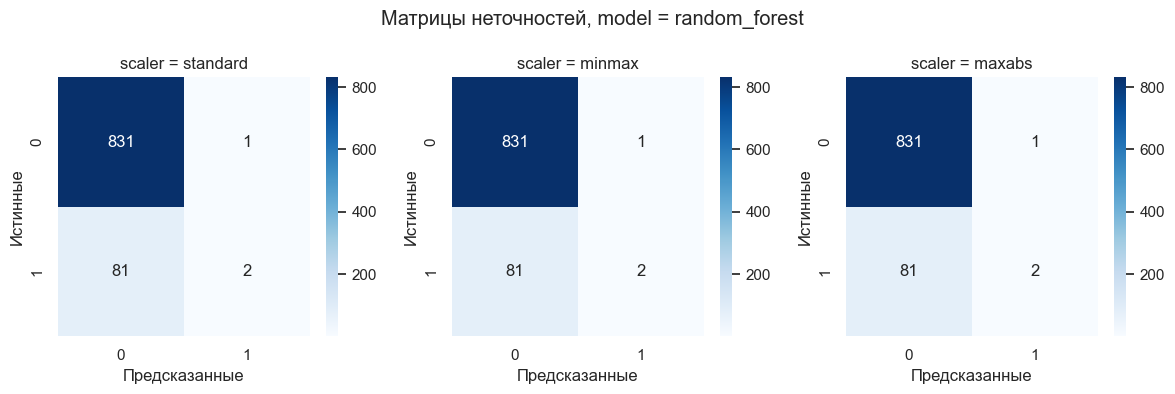

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

scaler_names = ["standard", "minmax", "maxabs"]
model_names = ["knn", "decision_tree", "logistic_regression", "random_forest"]

for model_name in model_names:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for i, scaler_name in enumerate(scaler_names):
        y_test_current = model_results[scaler_name][model_name]["y_test"]
        y_pred_current = model_results[scaler_name][model_name]["y_pred"]

        cm = confusion_matrix(y_test_current, y_pred_current)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
        axes[i].set_title("scaler = " + scaler_name)
        axes[i].set_ylabel("Истинные")
        axes[i].set_xlabel("Предсказанные")

    fig.suptitle("Матрицы неточностей, model = " + model_name)
    plt.tight_layout()
    plt.show()


По матрицам неточностей видно, что для всех методов сохраняется общий эффект дисбаланса классов: большинство объектов относится к классу 0, поэтому модели чаще предсказывают класс 0 и имеют большое число истинно отрицательных ответов.

Метод k-ближайших соседей показывает небольшое число истинно положительных ответов. Для StandardScaler получено 5 TP при 78 FN, а для MinMaxScaler и MaxAbsScaler значения TP ещё ниже. Это означает, что модель почти всегда выбирает класс 0 и слабо выявляет уволившихся сотрудников.

Дерево решений даёт наибольшее число истинно положительных ответов среди рассмотренных методов: 17 TP при StandardScaler и 19 TP при MinMaxScaler и MaxAbsScaler. При этом увеличивается число ложноположительных ответов (65–68 FP), то есть дерево решений чаще относит сотрудников к классу 1, что повышает полноту, но приводит к большему числу ложных срабатываний.

Логистическая регрессия в текущих настройках предсказывает класс 1 крайне редко. Для MinMaxScaler и MaxAbsScaler получено 1 TP при 82 FN, а для StandardScaler 2 TP при 81 FN. Это соответствует низкой полноте и подтверждает, что модель почти всегда выбирает класс 0.

Случайный лес также практически не выявляет класс 1: для всех скейлеров получено 2 TP при 81 FN. При этом число ложноположительных ответов минимально (1 FP), что указывает на крайне осторожную стратегию предсказаний.

Таким образом, по матрицам неточностей наиболее результативным по выявлению класса 1 является дерево решений. Для остальных методов основная ошибка связана с большим числом FN, то есть пропуском большинства уволившихся сотрудников.

# 7. ROC-кривая и AUC

Алгоритмы классификации могут возвращать не только метку класса, но и вероятность принадлежности к классу 1. Для оценки качества таких вероятностных прогнозов при разных порогах используется ROC-кривая.

ROC-кривая отражает зависимость между:
- True Positive Rate (TPR) – доля объектов класса 1, которые модель правильно отнесла к классу 1
- False Positive Rate (FPR) – доля объектов класса 0, которые модель ошибочно отнесла к классу 1

Формулы:

TPR = TP / (TP + FN)

FPR = FP / (FP + TN)

Порог классификации изменяется от минимального к максимальному значению, и для каждого порога вычисляются значения TPR и FPR, после чего строится график.

Для численного сравнения ROC-кривых используется площадь под кривой – AUC. Значение AUC = 0.5 соответствует случайному классификатору, а AUC = 1 соответствует идеальной модели.

На данном шаге ROC-кривые строятся для каждого метода на одном графике (4 линии) для сравнения. Для учёта влияния масштабирования графики строятся отдельно для StandardScaler, MinMaxScaler и MaxAbsScaler.


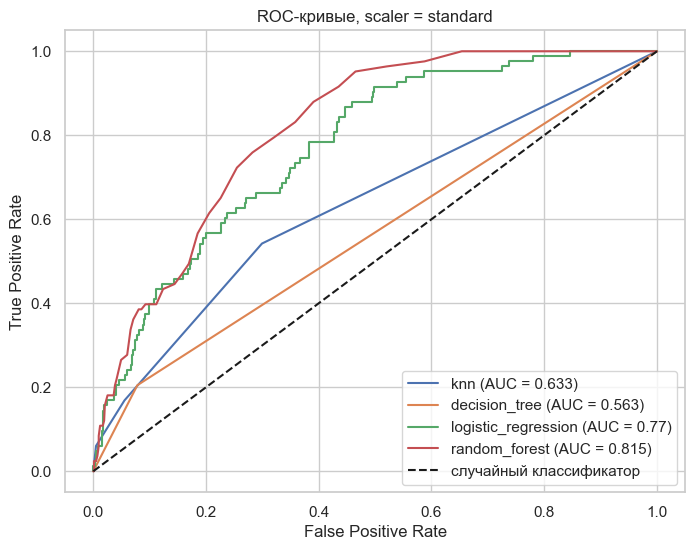

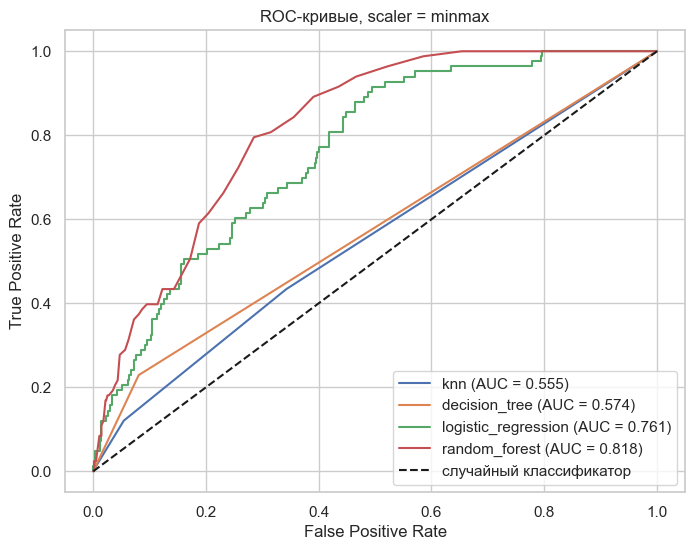

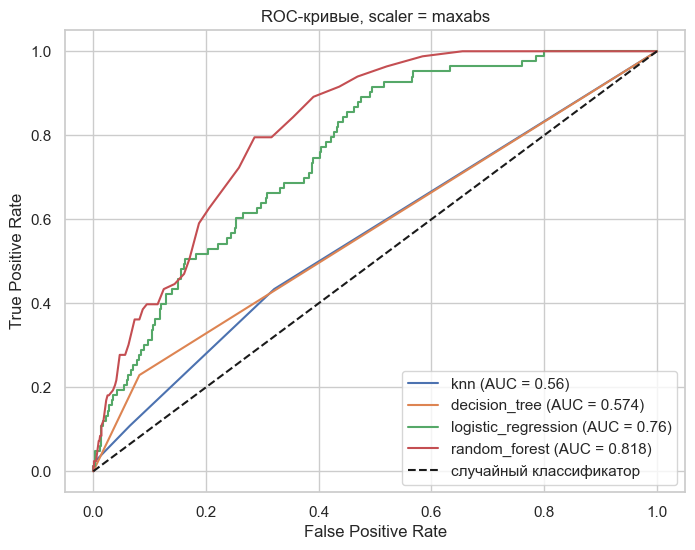

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve


model_order = ["knn", "decision_tree", "logistic_regression", "random_forest"]

for scaler_name in model_results:
    plt.figure(figsize=(8, 6))

    for model_name in model_order:
        y_test_current = model_results[scaler_name][model_name]["y_test"]
        y_proba_current = model_results[scaler_name][model_name]["y_proba"]

        fpr, tpr, _ = roc_curve(y_test_current, y_proba_current)
        auc_value = roc_auc_score(y_test_current, y_proba_current)

        plt.plot(
            fpr,
            tpr,
            label=model_name + " (AUC = " + str(round(auc_value, 3)) + ")",
        )

    plt.plot([0, 1], [0, 1], "k--", label="случайный классификатор")

    plt.title("ROC-кривые, scaler = " + scaler_name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()



По графикам ROC-кривых видно, что все методы дают результаты лучше случайного классификатора, так как значения AUC во всех случаях превышают 0.5.

Для StandardScaler наибольшее значение AUC получено у случайного леса (AUC = 0.815). Далее следует логистическая регрессия (AUC = 0.77). Метод k-ближайших соседей показывает AUC = 0.633, а дерево решений – AUC = 0.563, то есть их ROC-кривые ближе к диагонали и разделяющая способность ниже.

Для MinMaxScaler наибольшее значение AUC также у случайного леса (AUC = 0.818). Логистическая регрессия показывает AUC = 0.761. Для kNN и дерева решений получены более низкие значения AUC (0.555 и 0.574 соответственно).

Для MaxAbsScaler результаты аналогичны: случайный лес показывает AUC = 0.818, логистическая регрессия – AUC = 0.76. Для kNN и дерева решений получены значения AUC = 0.56 и AUC = 0.574.

Таким образом, по качеству вероятностных прогнозов наилучшим методом является случайный лес, так как его ROC-кривая наиболее удалена от диагонали и значение AUC максимальное для всех способов масштабирования. Второе место занимает логистическая регрессия. Для kNN заметно влияние масштабирования: при StandardScaler значение AUC выше, чем при MinMaxScaler и MaxAbsScaler. Дерево решений по ROC AUC демонстрирует наименьшую разделяющую способность в рамках выполненного сравнения.

# 8. Вывод о качестве построенного классификатора

В ходе работы решалась задача бинарной классификации – предсказание факта увольнения сотрудника (Attrition = 1) по признакам из набора employee_attrition.csv.

Данные были предварительно обработаны: выполнена проверка категориальных значений на неявные дубликаты, проверены и удалены явные дубликаты, исправлены нетипичные значения distance_from_home_km. Для использования моделей выполнено прямое кодирование категориальных признаков и сформированы три варианта масштабирования числовых признаков: StandardScaler, MinMaxScaler и MaxAbsScaler.

По рассчитанным метрикам видно, что высокая Accuracy (около 0.85–0.91) достигается у всех методов, однако из-за дисбаланса целевой переменной эта метрика недостаточно информативна для оценки качества выявления класса 1.

При оценке качества выявления уволившихся сотрудников ключевыми являются Recall, F1 score и Balanced accuracy. По этим метрикам наилучшие результаты показывает дерево решений: Recall = 0.228916 и максимальные значения F1 score и Balanced accuracy среди рассмотренных вариантов. Матрицы неточностей подтверждают данный вывод: дерево решений даёт наибольшее число истинно положительных ответов, хотя при этом увеличивает число ложноположительных ответов.

Метод k-ближайших соседей и логистическая регрессия в текущей настройке слабо выявляют класс 1, что выражается в малом числе истинно положительных ответов и большом числе ложноотрицательных ошибок.

По ROC AUC наилучшие результаты показывает случайный лес (AUC около 0.815–0.818 для всех способов масштабирования), что говорит о хорошей способности ранжировать объекты по вероятности класса 1. При этом при фиксированном пороге классификации данный метод даёт крайне низкий Recall, то есть пропускает большую часть уволившихся сотрудников.

Таким образом, при использовании фиксированного порога и приоритетной задаче выявления класса 1 наиболее результативным классификатором на данном этапе является дерево решений. Если требуется оценивать и сравнивать вероятностные прогнозы и подбирать порог классификации, то по ROC AUC наиболее качественные вероятности демонстрирует случайный лес.


# 9. Дополнительные задания

## Задание 9

Построить дерево решений в текстовом и графовом формате.

### 9.1 Построение дерева решений в текстовом и графовом формате

Для визуализации используется библиотека graphviz и функция export_graphviz для построения графа, а также функция export_text для вывода структуры дерева в виде последовательности правил.

На первом шаге из ранее сохранённых результатов выбирается обученная модель дерева решений и соответствующие ей признаки обучающей выборки. Далее выполняется экспорт дерева в формат dot и визуализация графа, где в узлах отображаются условия разбиения и распределение объектов по классам.

На втором шаге дерево экспортируется в текстовом виде. В текстовом представлении каждая строка соответствует проверке условия или листовому узлу, а отступы показывают уровень вложенности в структуре дерева. Это позволяет проследить последовательность правил, по которым модель принимает решения.


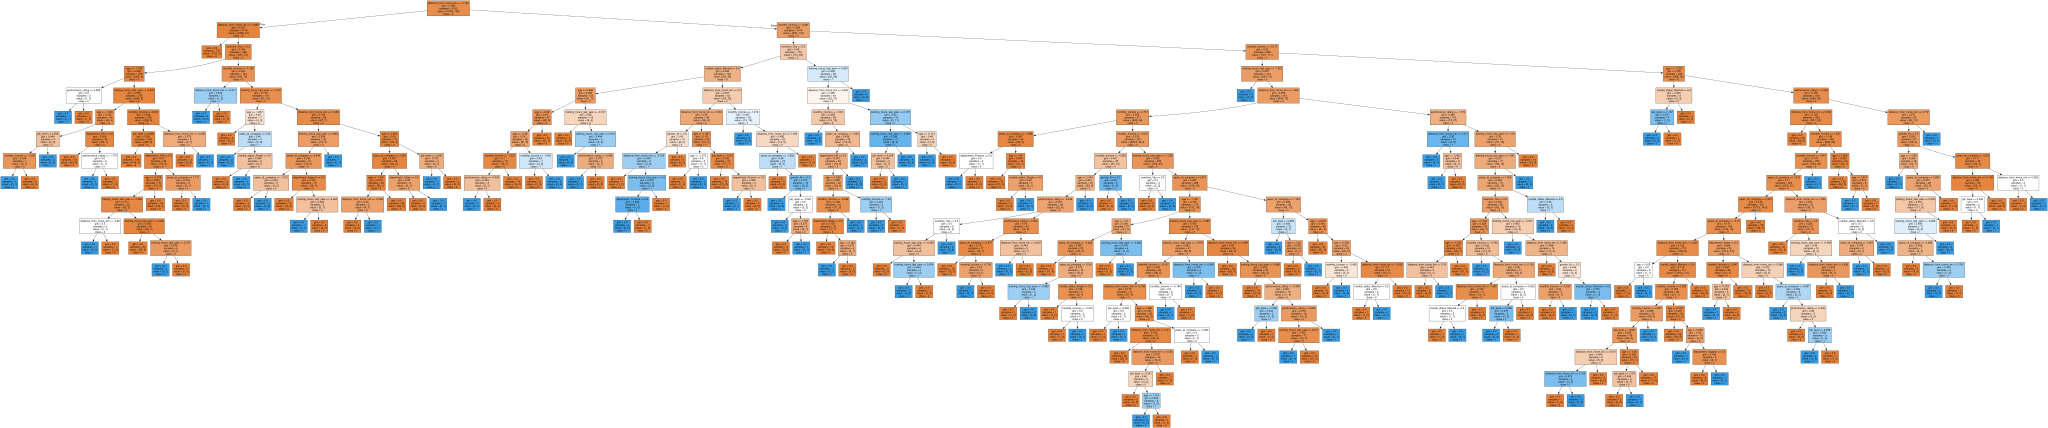

|--- distance_from_home_km <= -0.18
|   |--- distance_from_home_km <= -0.49
|   |   |--- class: 0
|   |--- distance_from_home_km >  -0.49
|   |   |--- overtime_Yes <= 0.50
|   |   |   |--- age <= -1.72
|   |   |   |   |--- performance_rating <= 0.91
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- performance_rating >  0.91
|   |   |   |   |   |--- class: 0
|   |   |   |--- age >  -1.72
|   |   |   |   |--- training_hours_last_year <= -0.87
|   |   |   |   |   |--- age <= -1.35
|   |   |   |   |   |   |--- job_level <= 0.26
|   |   |   |   |   |   |   |--- monthly_income <= -1.01
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- monthly_income >  -1.01
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- job_level >  0.26
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- age >  -1.35
|   |   |   |   |   |   |--- department_HR <= 0.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- departmen

In [30]:
from sklearn import tree
from sklearn.tree import export_text
import graphviz

# Выбор обученной модели дерева решений для standard scaler
Tree_model = model_results["standard"]["decision_tree"]["model"]
X_train_standard = scaled_data["standard"]["X_train"]

feature_names = X_train_standard.columns.tolist()

# построение дерева решений в графовом формате с помощью graphviz
dot_data = tree.export_graphviz(
    Tree_model,
    out_file=None,
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
)

graph = graphviz.Source(dot_data)
display(graph)

# экспорт дерева решений в текстовом формате
tree_text = export_text(Tree_model, feature_names=feature_names)
print(tree_text)


### Выводы по заданию 9

В результате выполнения дополнительного задания было построено дерево решений для задачи классификации факта увольнения сотрудника в графовом и текстовом форматах.

Графическое представление дерева позволяет наглядно увидеть, какие признаки и пороги используются моделью при разбиении выборки на подгруппы, а также оценить глубину дерева и структуру принимаемых решений.

Текстовое представление дерева в виде последовательности вложенных правил показывает, как модель пошагово переходит от корневого узла к листовым, последовательно уточняя условия. Это позволяет интерпретировать, по каким сочетаниям признаков модель относит сотрудников к классам 0 и 1.

![tree](graphviz-tree-schema.svg)

## Задание 10

Осуществить подбор оптимальных параметров с помощью GridSearchCV для случайного леса. Сравнить качество модели для подобранных параметров и любых других.

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# выбор обучающих и тестовых данных для standard scaler
X_train_standard = scaled_data["standard"]["X_train"]
X_test_standard = scaled_data["standard"]["X_test"]
y_train_standard = scaled_data["standard"]["y_train"]
y_test_standard = scaled_data["standard"]["y_test"]

# базовая модель случайного леса
base_model = RandomForestClassifier(n_estimators=100, random_state=seed)

# сетка гиперпараметров для подбора
param_grid = {
    # число деревьев в ансамбле
    "n_estimators": [10, 25, 50, 100, 150, 200],

    # максимальная глубина отдельного дерева
    # None = без ограничения глубины
    "max_depth": [None, 2, 5, 8, 10, 12, 16, 20],

    # минимальное число объектов для разбиения узла
    "min_samples_split": [2, 4, 6, 8, 10],

    # минимальное число объектов в листовом узле
    "min_samples_leaf": [1, 2, 4, 6],

    # число признаков, используемых при разбиении в каждом узле
    "max_features": ["sqrt", "log2", None],
}


# подбор гиперпараметров по сбалансированной точности
# cv – число разбиений на обучающие и валидационные подвыборки (кросс-валидация)
# scoring – метрика качества, по которой выбираются лучшие гиперпараметры
# n_jobs – число параллельных задач, -1 означает использование всех доступных ядер
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_standard, y_train_standard)

print("лучшие гиперпараметры случайного леса:")
print(grid_search.best_params_)

# сравнение качества базовой модели и модели с подобранными параметрами
best_model = grid_search.best_estimator_

base_model.fit(X_train_standard, y_train_standard)

y_pred_base = base_model.predict(X_test_standard)
y_pred_best = best_model.predict(X_test_standard)

rows = []

for name, y_pred in [
    ("baseline_random_forest", y_pred_base),
    ("tuned_random_forest", y_pred_best),
]:
    acc = accuracy_score(y_test_standard, y_pred)
    prec = precision_score(y_test_standard, y_pred, zero_division=0)
    rec = recall_score(y_test_standard, y_pred, zero_division=0)
    f1 = f1_score(y_test_standard, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test_standard, y_pred)

    rows.append(
        {
            "model": name,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "balanced_accuracy": bal_acc,
        }
    )

rf_compare_df = pd.DataFrame(rows)

print()
print("сравнение метрик для базовой и настроенной моделей случайного леса:")
display(rf_compare_df)



лучшие гиперпараметры случайного леса:
{'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 10}

сравнение метрик для базовой и настроенной моделей случайного леса:


,model,accuracy,precision,recall,f1_score,balanced_accuracy
0,baseline_random_forest,0.910383,0.666667,0.024096,0.046512,0.511447
1,tuned_random_forest,0.903825,0.368421,0.084337,0.137255,0.534957


### Выводы по заданию 10

В рамках данного дополнительного задания для модели случайного леса был выполнен подбор гиперпараметров с помощью GridSearchCV.

В результате подбора гиперпараметров для случайного леса с помощью GridSearchCV были получены следующие оптимальные значения: max_depth = 12, max_features = None, min_samples_leaf = 1, min_samples_split = 4, n_estimators = 10. Подбор выполнялся по метрике сбалансированной точности, что позволяет учитывать дисбаланс классов целевой переменной Attrition.

Сравнение базовой и настроенной моделей показало, что у базового случайного леса Accuracy немного выше (0.910383 против 0.903825), однако при этом значения Recall и Balanced accuracy остаются низкими (Recall = 0.024096, Balanced accuracy = 0.511447). У настроенной модели Recall возрастает до 0.084337, а Balanced accuracy – до 0.534957, то есть модель лучше выявляет класс 1 и более равномерно работает по обоим классам. При этом точность и F1 score несколько снижаются, что связано с увеличением числа ложноположительных ответов.

Таким образом, настройка гиперпараметров случайного леса позволяет улучшить полноту и сбалансированную точность за счёт небольшого снижения общей доли верных ответов и точности. В задачах, где приоритетом является выявление объектов класса 1, настроенная модель оказывается более предпочтительной по сравнению с базовой.

## Задание 14

Написать программу, которая для дерева решений для разного параметра max_depth будет считать accuracy_score для тренировочных и тестовых данных (использовать predict на X_train и X_valid). Выполнить визуализацию: по оси х - значение параметра max_depth (от 1 до 16), по оси y - Accuracy, построить две линии для тренировочных и тестовых данных.

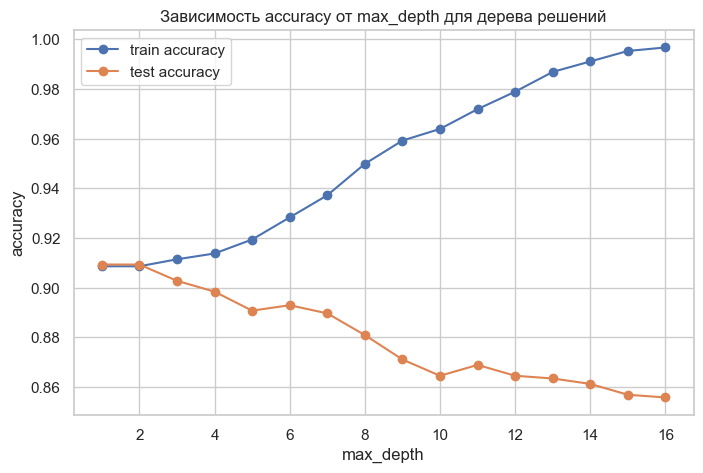

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# выбор обучающих и тестовых данных для standard scaler
# X_train_standard – обучающая выборка признаков
# X_test_standard – тестовая выборка признаков (аналог валидационной выборки X_valid)
# y_train_standard, y_test_standard – соответствующие целевые переменные
X_train_standard = scaled_data["standard"]["X_train"]
X_test_standard = scaled_data["standard"]["X_test"]
y_train_standard = scaled_data["standard"]["y_train"]
y_test_standard = scaled_data["standard"]["y_test"]

# диапазон значений max_depth, для которых будет оцениваться качество
max_depth_values = list(range(1, 17))
train_accuracies = []  # accuracy на обучающей выборке
test_accuracies = []  # accuracy на тестовой (валидационной) выборке

for current_max_depth in max_depth_values:
    # обучение дерева решений с разной максимальной глубиной
    dt_model = DecisionTreeClassifier(max_depth=current_max_depth, random_state=seed)
    dt_model.fit(X_train_standard, y_train_standard)

    # получение предсказаний для обучающей выборки X_train_standard (predict на X_train)
    y_train_pred = dt_model.predict(X_train_standard)
    train_acc = accuracy_score(y_train_standard, y_train_pred)
    train_accuracies.append(train_acc)

    # получение предсказаний для тестовой выборки X_test_standard (predict на X_valid)
    y_test_pred = dt_model.predict(X_test_standard)
    test_acc = accuracy_score(y_test_standard, y_test_pred)
    test_accuracies.append(test_acc)

# визуализация зависимости accuracy от max_depth для обучающей и тестовой выборок
plt.figure(figsize=(8, 5))
plt.plot(max_depth_values, train_accuracies, marker="o", label="train accuracy")
plt.plot(max_depth_values, test_accuracies, marker="o", label="test accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Зависимость accuracy от max_depth для дерева решений")
plt.grid(True)
plt.legend()
plt.show()



### Выводы по заданию 14

По графику зависимости accuracy от max_depth видно, что при увеличении глубины дерева точность на обучающей выборке монотонно растёт и при больших значениях max_depth почти достигает 1. Это означает, что модель с большой глубиной практически запоминает обучающие данные и очень хорошо подстраивается под обучающую выборку.

При этом точность на тестовой выборке ведёт себя иначе: при небольших значениях max_depth (примерно 2–3) она находится на максимальном уровне, а затем постепенно снижается по мере роста глубины дерева. Увеличение разрыва между кривыми train accuracy и test accuracy при больших max_depth указывает на переобучение – модель хорошо описывает обучающие данные, но её обобщающая способность на новых данных ухудшается.

Таким образом, по результатам анализа зависимости accuracy от max_depth наиболее разумным является выбор умеренной глубины дерева решений. Слишком глубокие деревья приводят к переобучению и снижению качества на тестовой выборке, тогда как модели с небольшой или средней глубиной обеспечивают более устойчивое качество на новых данных.